# 15 动态规划

## 15.1 爬楼梯

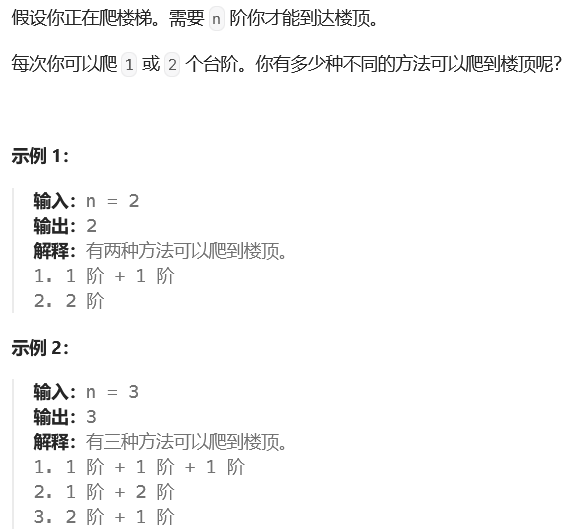

In [ ]:
class Solution:
    def climbStairs(self, n: int) -> int:
        if n <= 2:
            return n
        a,b = 1,2
        for _ in range(3,n+1):
            a,b = b,a+b
        return b

## 15.2 杨辉三角

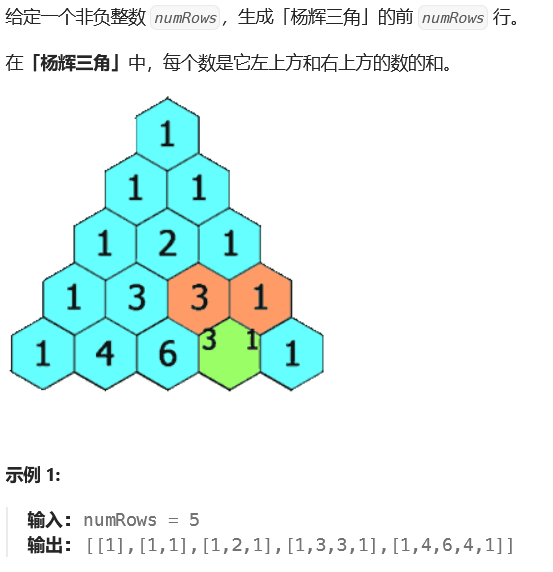

In [ ]:
class Solution:
    def generate(self, numRows: int) -> List[List[int]]:
        res = []
        for i in range(numRows):
            row = [1] * (i + 1)
            if i >= 2:
                for j in range(1,i):
                    row[j] = res[i-1][j-1] + res[i-1][j]
            res.append(row)
        return res

## 15.3 打家劫舍

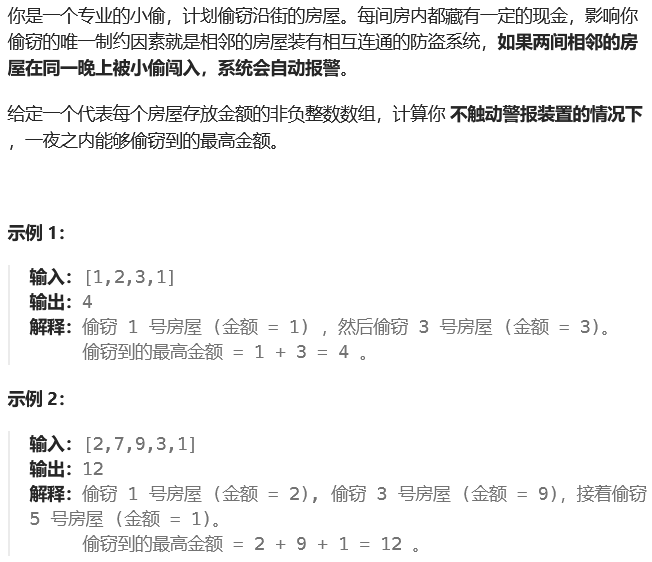

In [ ]:
from typing import List  # 这个是类型注解，必须加才能运行
# 状态转移是 dp[i] = max(dp[i-1],dp[i-2] + num[i])
class Solution:
    def rob(self, nums: List[int]) -> int:
        # nums 数组：每个数字代表这一户人家有多少钱
        n = len(nums)  # 总共有多少户人家
        
        # 边界情况：没有房子 → 偷 0
        if n == 0:
            return 0
        # 只有1户 → 只能偷这一户
        if n == 1:
            return nums[0]
        
        # 核心：用两个变量代替数组，节省空间
        # a = 到前前一户为止，最大能偷多少钱
        # b = 到前一户为止，最大能偷多少钱
        a, b = nums[0], max(nums[0], nums[1])

        # 从第3户开始遍历（索引2）
        for i in range(2, n):
            a, b = b, max(b, a + nums[i])
        
        # 最后 b 就是到最后一户为止的最大值
        return b

## 15.4 完全平方数

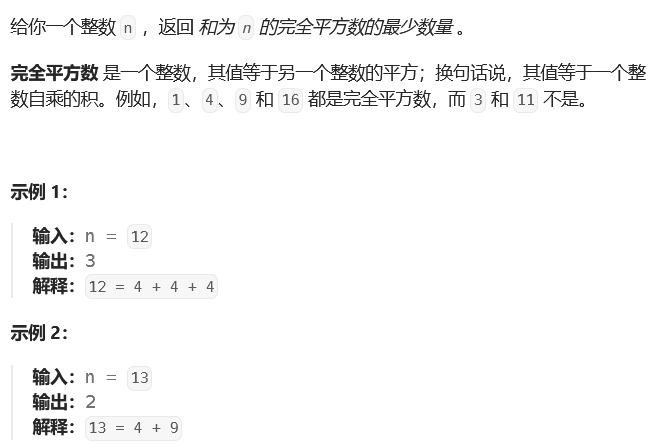

In [ ]:
class Solution:
    def numSquares(self, n: int) -> int:
        dp = [float('inf')] * (n + 1)
        dp[0] = 0
        # dp[i] = min(dp[i], dp[i - j*j] + 1)
        for i in range(1, n + 1):
            j = 1
            while j * j <= i:
                dp[i] = min(dp[i], dp[i - j * j] + 1)
                j += 1

        return dp[n]

## 15.5 零钱兑换

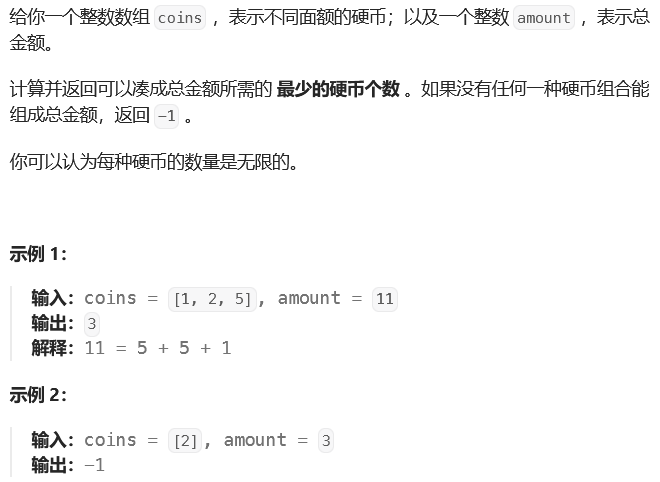

输入：coins = [1, 2, 5], amount = 11  
输出：3 dp[11] = min(dp[10], dp[9], dp[6]) + 1 = 3

In [ ]:
class Solution:
    def coinChange(self, coins: List[int], amount: int) -> int:
        # 初始化：最多用 amount 个 1 元硬币，所以 amount+1 代表不可能
        max_val = amount + 1
        dp = [max_val] * (amount + 1)
        dp[0] = 0  #  base case
        
        for i in range(1, amount + 1):
            for coin in coins:
                # 硬币面额不超过当前金额，才能使用
                if coin <= i:
                    dp[i] = min(dp[i], dp[i - coin] + 1)
        
        # 最终结果如果还是初始值，说明无法凑出
        return dp[amount] if dp[amount] != max_val else -1

## 15.6 单词拆分

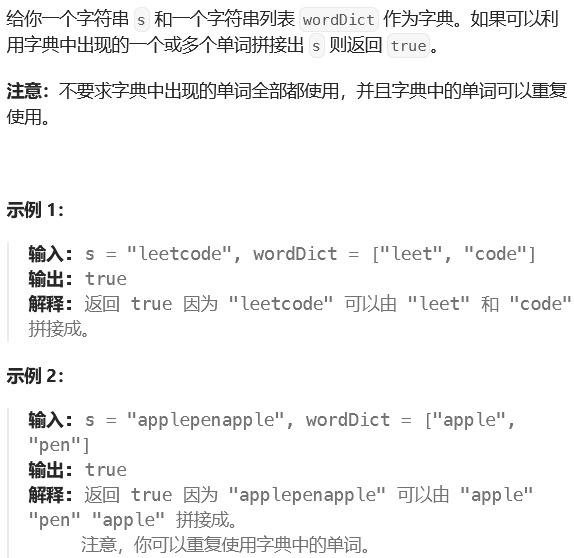

In [ ]:
class Solution:
    def wordBreak(self, s: str, wordDict: List[str]) -> bool:
        word_set = set(wordDict)
        n = len(s)
        dp = [False]*(n+1)
        dp[0] = True
        for i in range(1,n+1):
            for j in range(0,i):
                if dp[j] and s[j:i] in word_set:
                    dp[i] = True
                    break
        return dp[n]

## 15.7 最长递增子序列

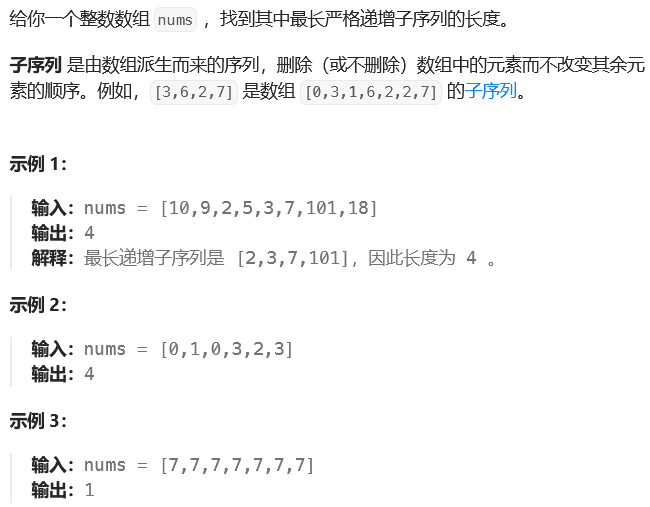

In [ ]:
class Solution:
    def lengthOfLIS(self, nums: List[int]) -> int:
        if not nums:
            return 0
        n = len(nums)
        # dp[i] 表示以nums[i]结尾的最长递增子序列长度
        dp = [1] * n
        
        for i in range(n):
            # 遍历i之前的所有元素
            for j in range(i):
                if nums[j] < nums[i]:
                    # 更新dp[i]
                    dp[i] = max(dp[i], dp[j] + 1)
        # 答案是dp数组的最大值
        return max(dp)

## 15.8 乘积最大子数组

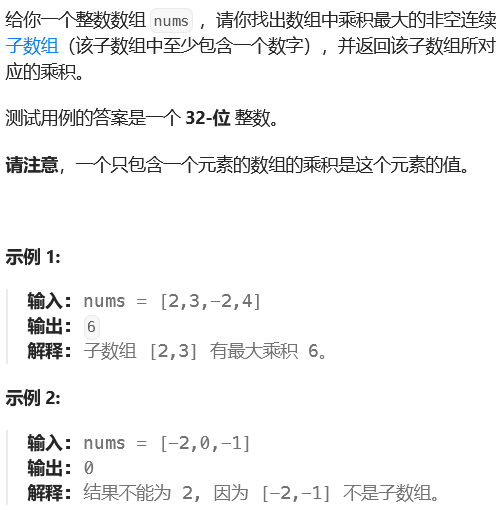

In [ ]:
class Solution:
    def maxProduct(self, nums: List[int]) -> int:
        if not nums:
            return 0
        res = pre_max = pre_min = nums[0]
        for num in nums[1:]:
            # 先暂存，避免值被覆盖
            temp_max = pre_max
            pre_max = max(num, temp_max*num, pre_min*num)
            pre_min = min(num, temp_max*num, pre_min*num)
            res = max(res, pre_max)
        return res

## 15.9 分割等和子集

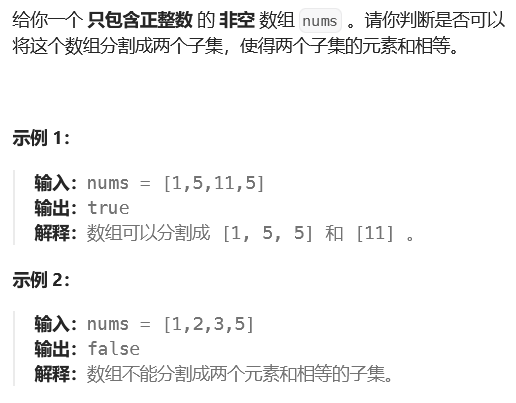

In [ ]:
class Solution:
    def canPartition(self, nums: List[int]) -> bool:
        total = sum(nums)
        # 总和奇数直接不行
        if total % 2 != 0:
            return False
        target = total // 2
        dp = [False] * (target + 1)
        dp[0] = True  # 和为0一定能凑
        
        for num in nums:
            # 倒序遍历，避免重复选取同一元素
            for j in range(target, num - 1, -1):
                dp[j] = dp[j] or dp[j - num]
        return dp[target]

## 15.10 最长有效括号

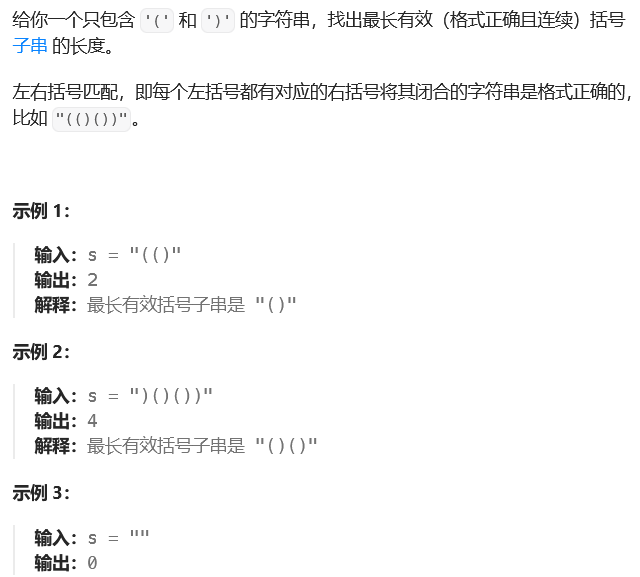

In [ ]:
class Solution:
    def longestValidParentheses(self, s: str) -> int:
        stack = [-1]  # 关键：基准位
        max_len = 0
        
        for i in range(len(s)):
            if s[i] == '(':
                stack.append(i)
            else:
                stack.pop()
                if not stack:
                    stack.append(i)
                else:
                    # 计算当前有效长度
                    current = i - stack[-1]
                    max_len = max(max_len, current)
        
        return max_len